# 13회차 - 상관관계 분석
수치 변수끼리 상관계수 계산 후, 히트맵으로 본다.
서로 닮은 변수(다중공선성)와 예측 대상과 친한 변수를 미리 찾음.

In [4]:
# ==============================================================
# 라이브러리 + 한글 폰트 자동 설정 + 폴더 보장 (셀2)
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform, os
import warnings
warnings.filterwarnings("ignore")

def set_korean_font():
    system = platform.system()
    if system == "Darwin":        # 맥
        plt.rcParams["font.family"] = "AppleGothic"
    elif system == "Windows":     # 윈도우
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:                          # 리눅스
        plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 80)

os.makedirs("../figures", exist_ok=True)

In [5]:
# ==============================================================
# 전처리 완료 데이터 로드 + 등급 점수(16개) (셀3) => 결과(행 개수, 열 개수)
# ==============================================================
df = pd.read_csv(
    "../../../data/processed/2_preprocess/step6_preprocess_eng.csv",
    encoding="utf-8-sig", low_memory=False
)

#날짜 컬럼 3개 -> 진짜 날짜타입으로 바꿈
for c in ["ABATT_DATE", "BIRTH_YMD", "JUDGE_DATE"]:
    df[c] = pd.to_datetime(df[c], errors="coerce") #날짜로 안바뀌면 NaT 결측값으로 처리

# 등급 → 숫자 (높을수록 좋은 등급)
grade_map = {"1++A":15,"1++B":14,"1++C":13,"1+A":12,"1+B":11,"1+C":10,
             "1A":9,"1B":8,"1C":7,"2A":6,"2B":5,"2C":4,"3A":3,"3B":2,"3C":1,"등외":0}
df["grade_num"] = df["LAST_GRADE"].map(grade_map)

print(f"데이터: {df.shape}")
print(f"grade_num 결측: {df['grade_num'].isnull().sum()}")

데이터: (2408699, 45)
grade_num 결측: 0


## 1.변수 그룹 정의

In [6]:
# ==============================================================
# 변수 그룹 (우리 데이터 컬럼명). (셀5)
# ==============================================================
# 한우 형질 (※ 육질은 등급 정답지 — 해석 주의)
cols_body = ["WEIGHT","BACKFAT","REA","INSFAT","YUKSAK","FATSAK",
             "TISSUE","GROWTH","AGE","WINDEX"]
# 농장
cols_farm = ["C2023","C2024","C2025","AREA","death_count"]
# 기상 (전 생애 THI 등급별 일수 + 평균) ※ days_폐사는 전부 0이라 제외
cols_weather = ["days_total","days_good","days_caution","days_warning","days_danger",
                "rn_day_mean","ws_davg_mean","ta_min_mean"]
# 예측 대상 (분류=grade_num, 회귀=COST_AMT)
cols_target = ["grade_num","COST_AMT"]

#각 변수 그룹에서 전체 컬럼중 실제로 있는것들만 반환하는 코드
def existing(cols): return [c for c in cols if c in df.columns]
cols_body, cols_farm = existing(cols_body), existing(cols_farm)
cols_weather, cols_target = existing(cols_weather), existing(cols_target)

#상관 히트맵에서 먼저 볼 핵심 변수 목록을 만드는 코드(cols_target : 예측 대상 변수들)
cols_key = existing(list(dict.fromkeys(
    cols_target + ["WEIGHT","AGE","INSFAT","days_danger","days_warning"]))) #대표 설명 변수ㄷ
print(f"핵심 변수 {len(cols_key)}개: {cols_key}")

핵심 변수 7개: ['grade_num', 'COST_AMT', 'WEIGHT', 'AGE', 'INSFAT', 'days_danger', 'days_warning']


## 2. 전체 상관행렬 계산

In [7]:
# ==============================================================
# 전체 수치 변수 Pearson 상관행렬 (셀7)
# ==============================================================
#상관분석에 사용할 전체 수치변수 목록 만드는 코드
num_cols = existing(list(dict.fromkeys( #중복 제거->리스트 변환->실제df에 존재하는 컬럼만 남김
    cols_body + cols_farm + cols_weather + cols_target)))
corr_pearson = df[num_cols].corr(method="pearson")
print(f"상관행렬 크기: {corr_pearson.shape}")

상관행렬 크기: (25, 25)


## 3. 핵심 변수 히트맵
빨강=양의 상관, 파랑=음의 상관, 흰색=무관.
대각선은 항상1(본인)

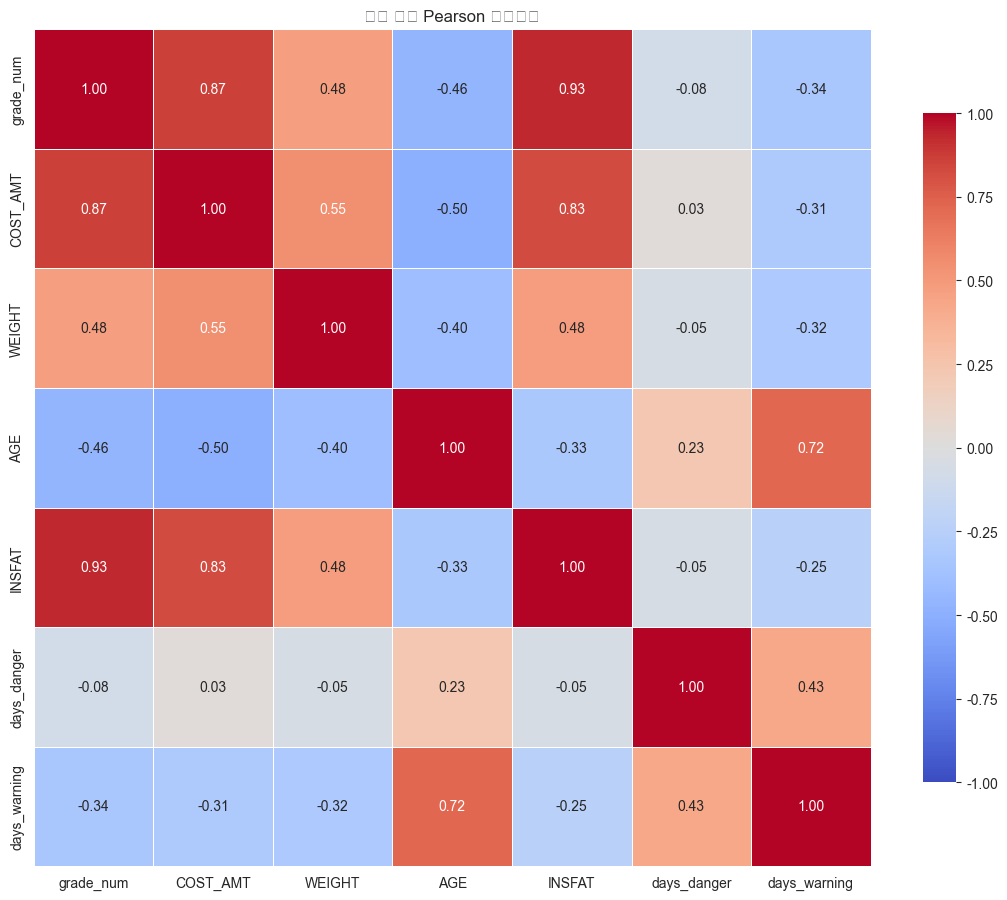

In [8]:
# ==============================================================
# 핵심 변수 히트맵 (셀9)
# ==============================================================
# ==============================================================
# grade_num(등급) 기준으로
# INSFAT(근내지방도가 높을수록 등급 좋음) 0.93
# 등급이 좋을수록 COST_AMT(가격)도 높음 0.87
# WEIGHT(무게)가 클수록 등급이 좋아지는 경향 0.48
# AGE(나이)가 많을수록 등급 낮아짐 -0.46
# days_경고(경고 일수)가 많을수록 등급 낮아짐 -0.34
# days_위험(위험 일수)와 등급 거의 관계 없음 -0.08
# ==============================================================
corr_key = df[cols_key].corr(method="pearson")
plt.figure(figsize=(11, 9))
sns.heatmap(corr_key, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("핵심 변수 Pearson 상관행렬")
plt.tight_layout()
plt.savefig("../../../figures/correlation/13_corr_key.png", dpi=100, bbox_inches="tight")
plt.show()

In [23]:
rename_map = {
    "days_양호": "days_good",
    "days_주의": "days_caution",
    "days_경고": "days_warning",
    "days_위험": "days_danger",
    "days_폐사": "days_death"
}

df = df.rename(columns=rename_map)
df.to_csv("../../../data/processed/2_preprocess/step6_preprocess_eng.csv",
          index=False, encoding="utf-8-sig")

## 4. 그룹별 히트맵(형질 / 기상 / 농장)

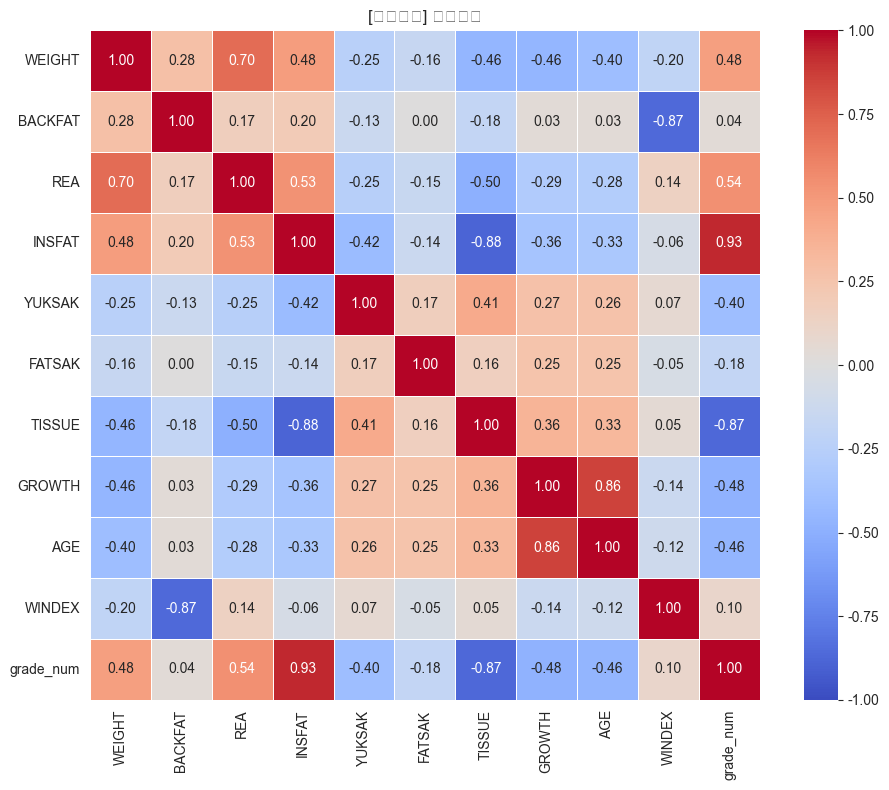

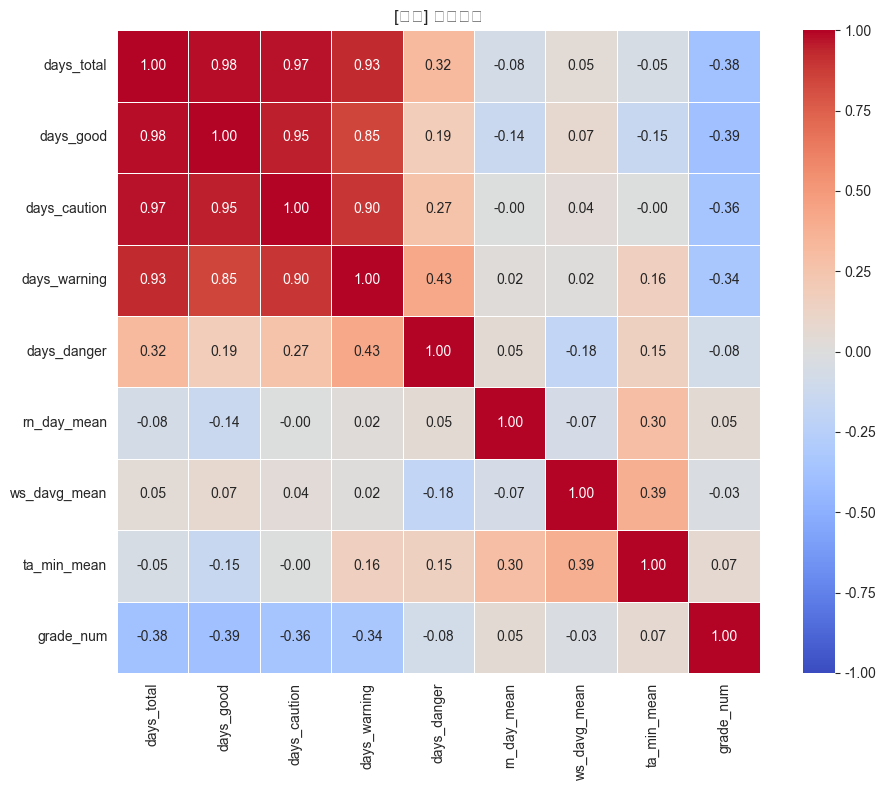

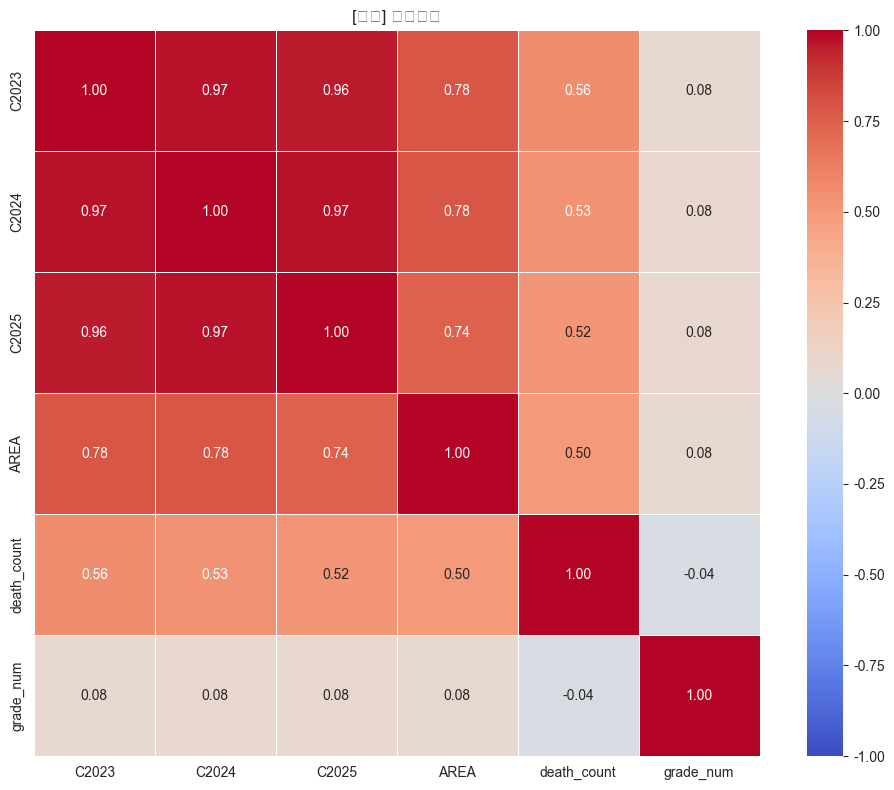

In [9]:
# ==============================================================
# 그룹별 히트맵
# ==============================================================
groups = {
    "한우형질": cols_body + ["grade_num"],
    "기상":     cols_weather + ["grade_num"],
    "농장":     cols_farm + ["grade_num"],
}
for name, cols in groups.items():
    #실세 존재하는 컬럼만 남기기
    cols = existing(list(dict.fromkeys(cols)))
    #컬럼 3개보다 적으면 히트맵 의미 약해서 그 그룹은 스킵
    if len(cols) < 3:
        continue
    #피어슨 상관행렬 계산
    corr = df[cols].corr(method="pearson")
    #그림 크기 설정
    plt.figure(figsize=(10, 8))
    #히트맵 그리기
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5)
    plt.title(f"[{name}] 상관행렬")
    #축 이름,제목이 잘리지않게 정리
    plt.tight_layout()
    plt.savefig(f"../../../figures/13_corr_{name}.png", dpi=100, bbox_inches="tight")
    plt.show()

## 5. 강한 상관 쌍 자동 추출 (|r| ≥ 0.7)

서로 너무 닮은 변수를 찾는다.
우리 데이터는 C2023~C2025(연도별 두수)와 days_* 끼리가 강하게 나올 것.

In [10]:
# ==============================================================
# 강한 상관 쌍 추출 (셀13) -> 다중공선성 ㅈㄴ많음
# ==============================================================
#상관계수 절대값 0.7 이상인 변수쌍만 뽑기
def get_high_corr_pairs(cm, threshold=0.7):
    #상관행렬 위쪽 삼각형만 남김
    upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))

    #행렬 형태를 변수쌍 목록 형태로 바꿈
    pairs = upper.unstack().dropna()

    #상관계수 절댓값 0.7 이상인것만 남김
    pairs = pairs[pairs.abs() >= threshold]

    #상관이 강한 순으로 정렬해서 반환
    return pairs.reindex(pairs.abs().sort_values(ascending=False).index)

THRESHOLD = 0.7

#전체 피어슨 상관에서 강한 상관쌍 추출
high_corr = get_high_corr_pairs(corr_pearson, THRESHOLD)
print(f"|r| >= {THRESHOLD}인 쌍: {len(high_corr)}개\n")
for (a, b), r in high_corr.items():
    print(f"  {a:15s} <-> {b:15s}  r = {r:+.3f}")

|r| >= 0.7인 쌍: 28개

  days_good       <-> days_total       r = +0.981
  C2025           <-> C2024            r = +0.974
  days_caution    <-> days_total       r = +0.972
  C2024           <-> C2023            r = +0.970
  C2025           <-> C2023            r = +0.958
  days_caution    <-> days_good        r = +0.946
  grade_num       <-> INSFAT           r = +0.930
  days_warning    <-> days_total       r = +0.928
  days_warning    <-> days_caution     r = +0.898
  TISSUE          <-> INSFAT           r = -0.885
  grade_num       <-> TISSUE           r = -0.874
  COST_AMT        <-> grade_num        r = +0.867
  WINDEX          <-> BACKFAT          r = -0.865
  AGE             <-> GROWTH           r = +0.858
  days_warning    <-> days_good        r = +0.846
  COST_AMT        <-> INSFAT           r = +0.827
  days_total      <-> AGE              r = +0.800
  days_good       <-> AGE              r = +0.799
  AREA            <-> C2023            r = +0.784
  AREA            <-> C2024   

## 6. days 변수의 "일수 함정" 확인

days_*가 AGE·days_total과 강하게 묶이는지 본다.
강하면 "더위 영향"이 아니라 "오래 산 것"일 수 있음 → 17회차 비율 변환 예정.

In [11]:
# ==============================================================
# days 변수가 사육기간과 얼마나 묶이는가 (셀15)
# ==============================================================
check_cols = existing(["AGE","days_total","days_good","days_warning","days_danger"])
print("사육기간 관련 변수 상관:")
print(df[check_cols].corr(method="pearson").round(2))

#관계	                    상관	    해석
# days_total ↔ days_good	0.98	전체 일수가 많으면 양호 일수도 많음
# days_total ↔ days_warning	0.93	전체 일수가 많으면 경고 일수도 많음
# AGE ↔ days_total	        0.80	나이가 많을수록 누적 일수가 많음
# AGE ↔ days_good	        0.80	오래 산 소는 양호 일수도 많음 ?
# AGE ↔ days_warning	    0.72	오래 산 소는 경고 일수도 많음 ?
# days_danger ↔ AGE	        0.23	위험 일수는 AGE와는 약한 관계

사육기간 관련 변수 상관:
               AGE  days_total  days_good  days_warning  days_danger
AGE           1.00        0.80       0.80          0.72         0.23
days_total    0.80        1.00       0.98          0.93         0.32
days_good     0.80        0.98       1.00          0.85         0.19
days_warning  0.72        0.93       0.85          1.00         0.43
days_danger   0.23        0.32       0.19          0.43         1.00


## 7. Pearson vs Spearman 비교

두 값이 크게 다른 쌍 = 곡선 관계 의심 → 14회차 산점도 확인.

In [12]:
# ==============================================================
# 두 방법 차이 분석 (셀17)
# ==============================================================
corr_p = df[cols_key].corr("pearson")
corr_s = df[cols_key].corr("spearman")
diff = (corr_p - corr_s).abs()
mask = np.triu(np.ones(diff.shape), k=1).astype(bool)
large_diff = diff.where(mask).stack()
large_diff = large_diff[large_diff > 0.1].sort_values(ascending=False)
print("Pearson과 Spearman 차이 큰 쌍 (곡선 관계 의심):\n")
for (a, b), d in large_diff.items():
    print(f"  {a:12s} <-> {b:12s}  P={corr_p.loc[a,b]:+.2f}, "
          f"S={corr_s.loc[a,b]:+.2f}, 차이={d:.2f}")

# 지표	       값	     의미
# Pearson	  -0.46	     AGE가 증가할수록 grade_num이 낮아지는 직선 경향이 중간 정도 있음
# Spearman	  -0.34	     순위 기준으로도 AGE가 높을수록 등급이 낮아지는 경향은 있음
# 차이	       0.12	     두 방식의 결과가 조금 다름

Pearson과 Spearman 차이 큰 쌍 (곡선 관계 의심):

  grade_num    <-> AGE           P=-0.46, S=-0.34, 차이=0.12


## 8. 예측 대상과의 상관 (분류=grade_num / 회귀=COST_AMT)

가장 중요. 단 육질 변수는 "정답지"라 높게 나와도 제출 모델엔 못 씀.

In [13]:
# ==============================================================
# 등급(grade_num)과의 상관
# ==============================================================
grade_corr = df[num_cols].corr()["grade_num"].drop("grade_num")
grade_corr = grade_corr.sort_values(key=abs, ascending=False)
print("=== grade_num과의 상관 (절댓값 큰 순) ===")
print(grade_corr.round(3))

=== grade_num과의 상관 (절댓값 큰 순) ===
INSFAT          0.930
TISSUE         -0.874
COST_AMT        0.867
REA             0.540
GROWTH         -0.481
WEIGHT          0.475
AGE            -0.465
YUKSAK         -0.402
days_good      -0.389
days_total     -0.383
days_caution   -0.359
days_warning   -0.337
FATSAK         -0.183
WINDEX          0.095
days_danger    -0.083
C2024           0.081
C2025           0.080
C2023           0.078
AREA            0.076
ta_min_mean     0.070
rn_day_mean     0.048
death_count    -0.043
BACKFAT         0.039
ws_davg_mean   -0.028
Name: grade_num, dtype: float64


In [14]:
# ==============================================================
# 가격(COST_AMT)과의 상관 (가격 있는 행만)
# ==============================================================
cost_corr = df[num_cols].corr()["COST_AMT"].drop("COST_AMT")
cost_corr = cost_corr.sort_values(key=abs, ascending=False)
print("=== COST_AMT와의 상관 (절댓값 큰 순) ===")
print(cost_corr.round(3))

=== COST_AMT와의 상관 (절댓값 큰 순) ===
grade_num       0.867
INSFAT          0.827
TISSUE         -0.746
REA             0.619
WEIGHT          0.550
GROWTH         -0.524
AGE            -0.505
days_good      -0.429
YUKSAK         -0.419
days_total     -0.394
days_caution   -0.361
days_warning   -0.306
FATSAK         -0.217
ta_min_mean     0.215
rn_day_mean     0.164
AREA            0.093
WINDEX          0.092
C2024           0.083
C2025           0.081
C2023           0.072
death_count    -0.056
BACKFAT         0.055
days_danger     0.031
ws_davg_mean   -0.019
Name: COST_AMT, dtype: float64


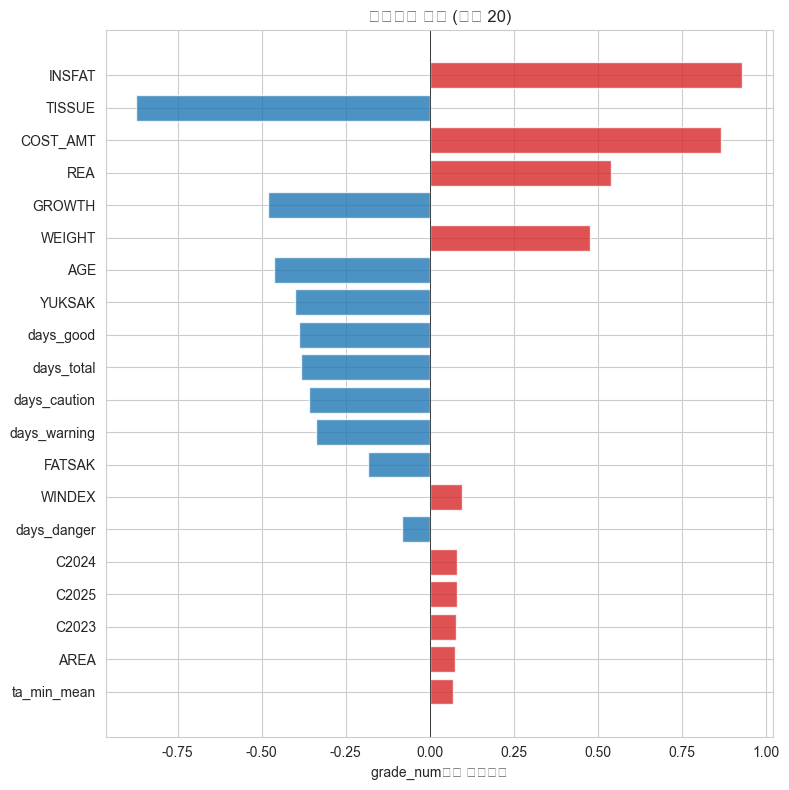

In [15]:
# ==============================================================
# 등급 상관 막대그래프 (셀21)
# ==============================================================
plt.figure(figsize=(8, 8))
top = grade_corr.head(20)
colors = ["#d62728" if v > 0 else "#1f77b4" for v in top]
plt.barh(range(len(top)), top.values, color=colors, alpha=0.8)
plt.yticks(range(len(top)), top.index)
plt.xlabel("grade_num과의 상관계수")
plt.title("등급과의 상관 (상위 20)")
plt.axvline(x=0, color="black", linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../../figures/13_grade_corr.png", dpi=100, bbox_inches="tight")
plt.show()

## 9. 다중공선성 처리 방침

방침: 변수는 일단 그대로 두고 회귀(20회차)에서 Lasso로 자동 정리.
LightGBM(분류)은 다중공선성에 둔감하므로 그대로 둬도 됨.

In [16]:
# ==============================================================
# 처리 방침 (지금은 제거 안 함)
# ==============================================================
remove_list = []   # 셀 13 결과 보고 명백한 중복만 후보에
if remove_list:
    df = df.drop(columns=[c for c in remove_list if c in df.columns])
    print(f"제거: {remove_list}")
else:
    print("변수 그대로 유지. 다중공선성은 20회차 Lasso로 처리.")

변수 그대로 유지. 다중공선성은 20회차 Lasso로 처리.


## 10. 저장

In [18]:
# ==============================================================
# 저장 (grade_num 추가됨)
# ==============================================================
os.makedirs("../../data/processed/3_eda", exist_ok=True)
df.to_csv("../../data/processed/3_eda/step7_corr.csv",
          index=False, encoding="utf-8-sig")
print(f"저장 완료: step7_corr.csv {df.shape}")

저장 완료: step7_corr.csv (2408699, 45)


## 11. 독립변수간 상관관계 히트맵

상관분석 대상 독립변수 수: 25개
['stn', 'WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'AGE', 'death_count', 'C2023', 'C2024', 'C2025', 'AREA', 'days_total', 'days_good', 'days_caution', 'days_warning', 'days_danger', 'days_death', 'rn_day_mean', 'ws_davg_mean', 'ta_min_mean']


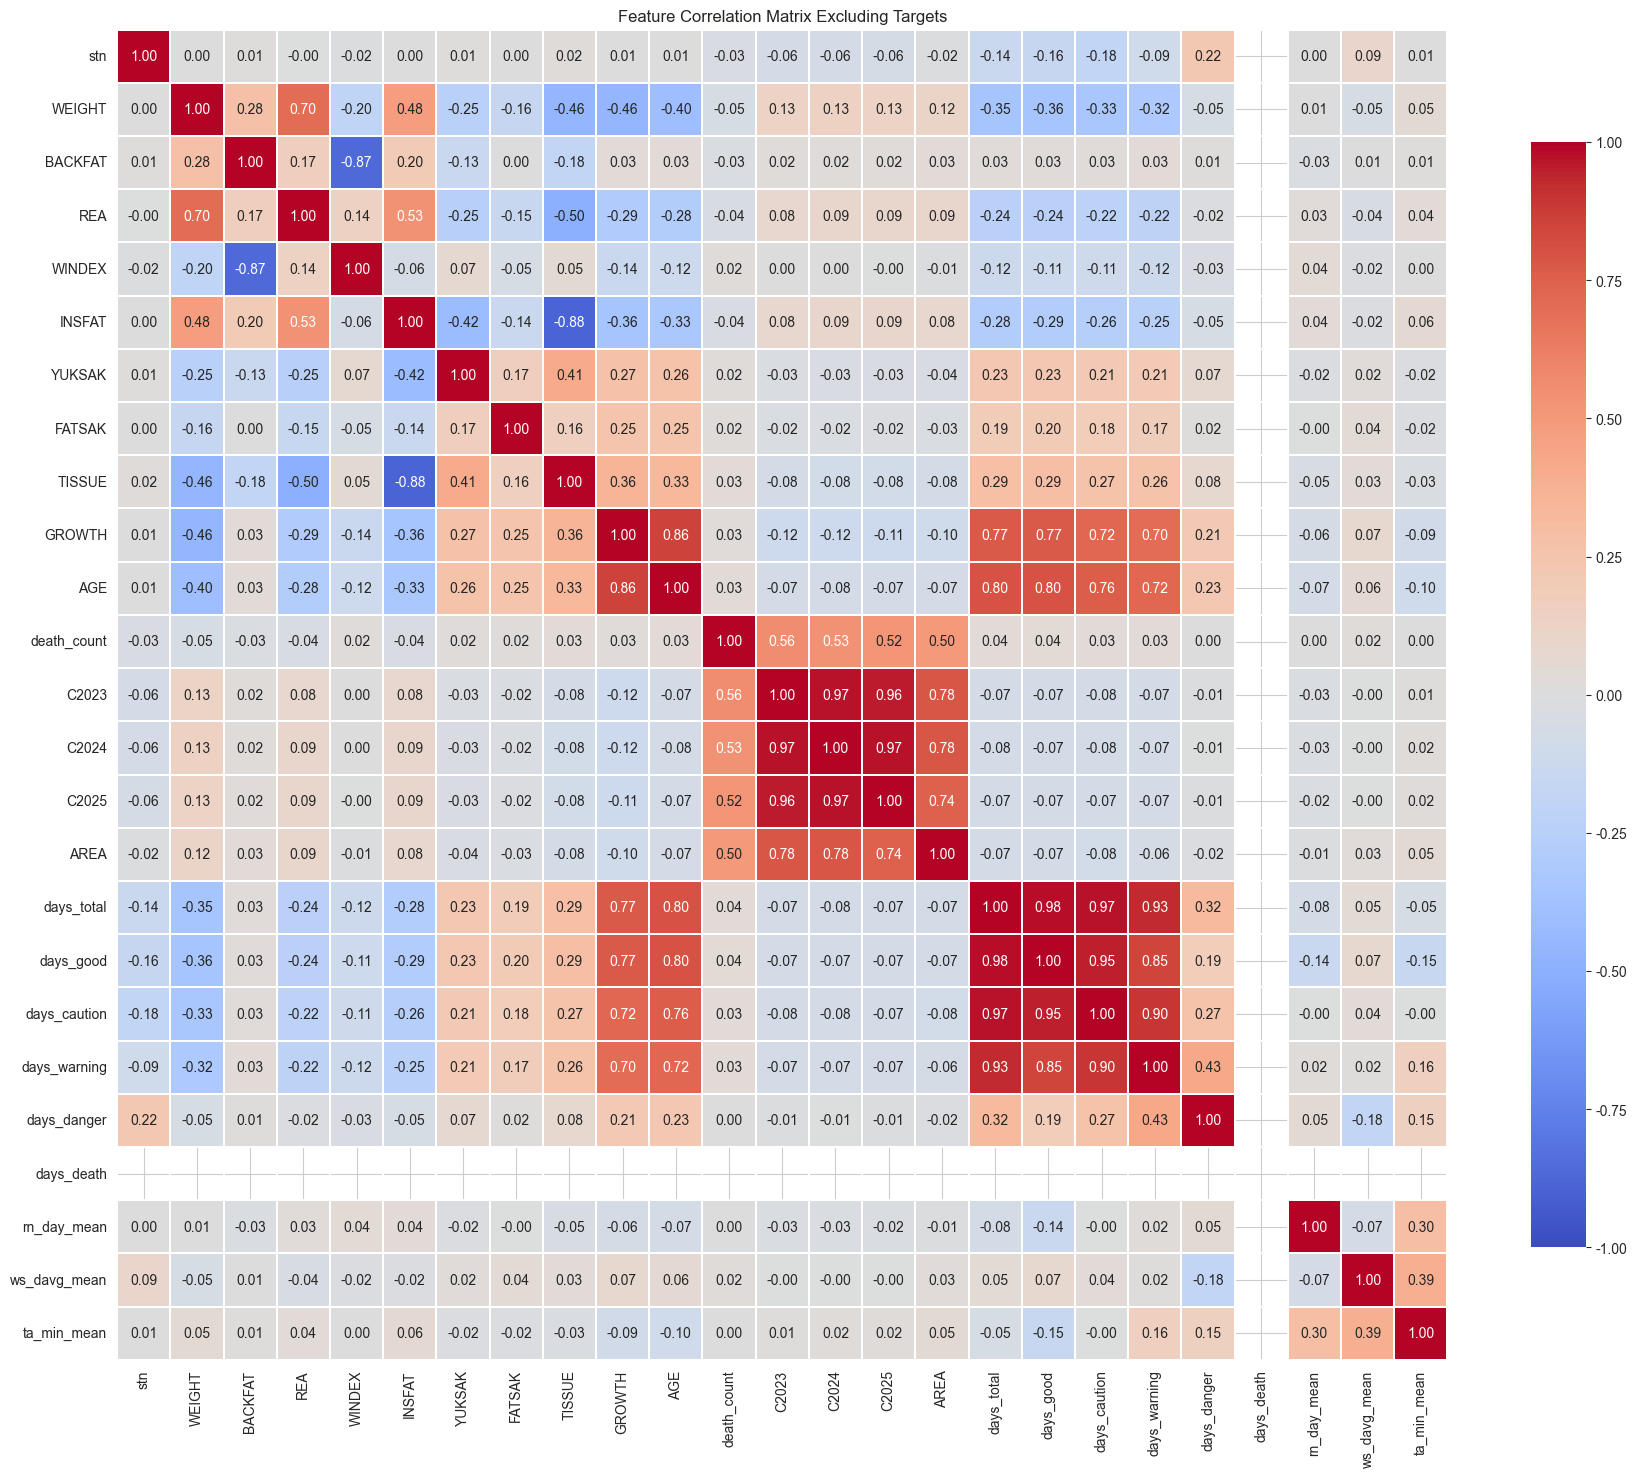

저장 완료: ../../hanwoo_contest/figurers/correlation/corr_all.png


In [19]:
# ==============================================================
# 전체 독립변수 간 상관관계 히트맵 저장
# ==============================================================

# 저장 폴더 생성
save_dir = "../../hanwoo_contest/figurers/correlation"
os.makedirs(save_dir, exist_ok=True)

# 종속변수 제외
target_cols = ["grade_num", "COST_AMT"]

# 전체 수치형 컬럼 중 종속변수 제외
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in all_numeric_cols if c not in target_cols]

print(f"상관분석 대상 독립변수 수: {len(feature_cols)}개")
print(feature_cols)

# 상관행렬 계산
corr_all = df[feature_cols].corr(method="pearson")

# 히트맵 생성
plt.figure(figsize=(18, 15))
sns.heatmap(
    corr_all,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Matrix Excluding Targets")
plt.tight_layout()

# 저장
save_path = f"{save_dir}/corr_all.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"저장 완료: {save_path}")

# 1. 농장규모 변수들이 매우 강하게 묶임
# C2023 ↔ C2024 = 0.97
# C2024 ↔ C2025 = 0.97
# C2023 ↔ C2025 = 0.96
# AREA ↔ C2023/C2024/C2025 = 약 0.74~0.78

# 2. 기상 days 변수들이 거의 한 덩어리임
# days_total ↔ days_good = 0.98
# days_total ↔ days_caution = 0.97
# days_total ↔ days_warning = 0.93
# days_good ↔ days_caution = 0.95
# days_caution ↔ days_warning = 0.90

# AGE ↔ days_total = 0.80
# AGE ↔ days_good = 0.80
# AGE ↔ days_caution = 0.76
# AGE ↔ days_warning = 0.72

# 3. 육질/도체 변수에 강한 관계
# WEIGHT ↔ REA = 0.70
# BACKFAT ↔ WINDEX = -0.87
# INSFAT ↔ TISSUE = -0.88
# AGE ↔ GROWTH = 0.86

# 4. days_death 빔
# 전부0이어서 상관계수 계산 안됌